# Multi-class classification on spirals with the micrograd engine

This is the first repo in a series — **micrograd → makemore → gpt** — and it does the smallest complete thing: train a classifier, from scratch, on a problem a linear model can't solve. The engine underneath is scalar. Every number is a `Value`, every operation registers its own backward closure, and one `loss.backward()` fills in gradients across the whole network. No tensors, no framework.

I use three interleaved spirals rather than the usual two moons for one reason: the spiral forces a curved, multi-class decision boundary, so it actually separates a model that can represent nonlinearity from one that can't. The arc below is deliberate — establish that the task is nonlinear (a linear baseline fails), then show the MLP solving it, then check it generalizes and say where it stops.

## Setup

Seed everything so the run, the accuracies, and the decision-boundary plot reproduce exactly. `SAVE_FIGS` regenerates the committed figure in `assets/`.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from micrograd.engine import Value
from micrograd.nn import MLP

random.seed(42)
np.random.seed(42)
SAVE_FIGS = True
ASSETS = Path('..') / 'assets'
%matplotlib inline

## The dataset

There's no `make_spirals` in scikit-learn, so I generate it: for each class, sweep the radius out from the center while rotating through a fixed arc, with the three classes offset by 120°. A little Gaussian jitter on the angle gives class overlap near the origin so the task isn't trivially separable. This is genuinely original data — not a library benchmark — and it's 2D and small, which is what a scalar engine can afford.

In [2]:
def make_spirals(points_per_class=33, n_classes=3, noise=0.15, revolutions=1.0, seed=0):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for c in range(n_classes):
        r = np.linspace(0.05, 1.0, points_per_class)
        base = c * 2 * np.pi / n_classes
        theta = np.linspace(base, base + revolutions * 2 * np.pi, points_per_class)
        theta = theta + rng.normal(0, noise, points_per_class)
        X.append(np.c_[r * np.cos(theta), r * np.sin(theta)])
        y += [c] * points_per_class
    return np.vstack(X), np.array(y)

X, y = make_spirals()
print(f'{len(X)} points, {len(set(y))} classes, {(y==0).sum()} per class')

99 points, 3 classes, 33 per class


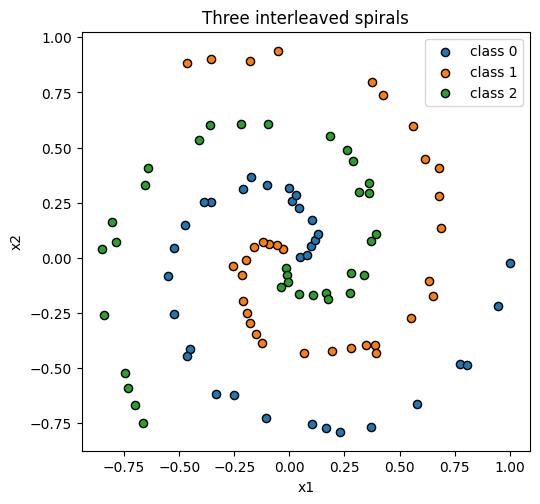

In [3]:
colors = ['tab:blue', 'tab:orange', 'tab:green']
plt.figure(figsize=(5.5, 5.5))
for c in range(3):
    plt.scatter(X[y==c,0], X[y==c,1], c=colors[c], edgecolor='k', s=35, label=f'class {c}')
plt.gca().set_aspect('equal'); plt.legend(); plt.title('Three interleaved spirals')
plt.xlabel('x1'); plt.ylabel('x2'); plt.tight_layout(); plt.show()

## Normalize, then split

Two preprocessing steps that matter. **Standardize** to zero mean and unit variance: tanh saturates for |pre-activation| ≫ 1, where its gradient `1 - t²` collapses and learning stalls, so keeping inputs near unit scale keeps the hidden units in their responsive range. And **hold out a test split** — the original demo I'm extending reported accuracy on the training data, which only tells you the model fit, not whether it generalized. On a 371-parameter network I want the honest number.

In [4]:
mu, sigma = X.mean(0), X.std(0)
Xn = (X - mu) / sigma

rng = np.random.default_rng(1)
idx = rng.permutation(len(Xn))
ntr = int(0.7 * len(Xn))
tr, te = idx[:ntr], idx[ntr:]
Xtr, ytr, Xte, yte = Xn[tr], y[tr], Xn[te], y[te]
print(f'train {len(tr)}  test {len(te)}')

train 69  test 30


## Loss and accuracy

The objective is softmax + negative log-likelihood, built straight out of engine primitives — `exp`, division, `log`. The engine doesn't know the closed-form softmax gradient; it rediscovers it from the chain rule through the shared denominator. I report the **mean** NLL (not the sum) so the learning rate doesn't silently depend on how many points are in the batch.

In [5]:
def softmax_nll(model, X, y):
    total = Value(0.0)
    for xi, yi in zip(X, y):
        logits = model([Value(xi[0]), Value(xi[1])])   # 3 linear logits
        counts = [l.exp() for l in logits]
        denom = sum(counts)
        p_true = counts[int(yi)] / denom               # softmax prob of the true class
        total = total + -p_true.log()                  # NLL
    return total * (1.0 / len(X))                       # mean

def accuracy(model, X, y):
    correct = 0
    for xi, yi in zip(X, y):
        logits = [l.data for l in model([Value(xi[0]), Value(xi[1])])]
        correct += int(np.argmax(logits) == yi)
    return correct / len(X)

## Baseline: is the task actually nonlinear?

Before reaching for a deep network, I check that the problem needs one. `MLP(2, [3])` is a single linear layer — a 9-parameter softmax classifier with no hidden units and no nonlinearity. If the spirals were linearly separable, it would do fine.

In [6]:
random.seed(42)
linear = MLP(2, [3])
for _ in range(80):
    L = softmax_nll(linear, Xtr, ytr)
    linear.zero_grad(); L.backward()
    for p in linear.parameters():
        p.data -= 0.5 * p.grad
print(linear)
print(f'linear baseline  test accuracy {accuracy(linear, Xte, yte):.2f}  ({len(linear.parameters())} params)')

MLP(2 -> 3; linear)
linear baseline  test accuracy 0.27  (9 params)


It lands around chance (three classes, so ~0.33). A linear boundary can't wrap around a spiral — no amount of training fixes that. The failure is the point: it tells me the curvature has to come from hidden nonlinear layers, which is exactly what the next model adds.

## The model

`MLP(2, [16, 16, 3])`: two coordinates in, two tanh-activated hidden layers of 16 units, and a **linear** 3-logit head. The linear head is the one design point worth pausing on — a classification head must emit unbounded logits so softmax can push probability arbitrarily close to 1. (An earlier version of this repo put tanh on the output too, which capped confidence at ~0.73 and floored the loss; the `nonlin=False` head fixes that.)

In [7]:
random.seed(42)
model = MLP(2, [16, 16, 3])
print(model)
print(f'{len(model.parameters())} parameters')

MLP(2 -> 16 -> 16 -> 3; hidden tanh, linear head)
371 parameters


## Training

Full-batch gradient descent. The one wrinkle is a learning-rate drop partway through: a large step (1.0) to descend quickly out of the initial plateau, then a smaller one (0.3) to settle without bouncing. Every epoch is the same four steps — forward to build the loss graph, `zero_grad`, `backward`, update.

In [8]:
epochs = 110
losses = []
for epoch in range(epochs):
    lr = 1.0 if epoch < 70 else 0.3
    loss = softmax_nll(model, Xtr, ytr)   # 1. forward
    model.zero_grad()                     # 2. reset grads
    loss.backward()                       # 3. backward
    for p in model.parameters():          # 4. SGD update
        p.data -= lr * p.grad
    losses.append(loss.data)
    if epoch % 20 == 0 or epoch == epochs - 1:
        print(f'epoch {epoch:3d}  mean NLL {loss.data:.3f}  train acc {accuracy(model, Xtr, ytr):.2f}')

epoch   0  mean NLL 2.287  train acc 0.41


epoch  20  mean NLL 1.002  train acc 0.52


epoch  40  mean NLL 0.585  train acc 0.71


epoch  60  mean NLL 0.385  train acc 0.90


epoch  80  mean NLL 0.226  train acc 0.99


epoch 100  mean NLL 0.194  train acc 0.99


epoch 109  mean NLL 0.183  train acc 0.99


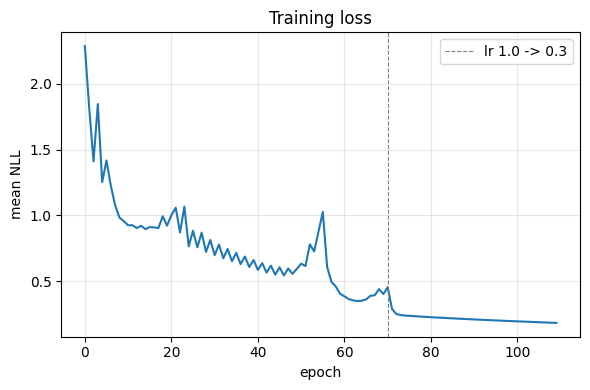

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(losses, color='tab:blue')
plt.axvline(70, ls='--', c='gray', lw=0.8, label='lr 1.0 -> 0.3')
plt.xlabel('epoch'); plt.ylabel('mean NLL'); plt.title('Training loss'); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Does it generalize?

Train accuracy tells me the network fit; the held-out split tells me whether it learned the shape or memorized the points.

In [10]:
tr_acc = accuracy(model, Xtr, ytr)
te_acc = accuracy(model, Xte, yte)
print(f'train accuracy {tr_acc:.2f}')
print(f'test  accuracy {te_acc:.2f}')

train accuracy 0.99
test  accuracy 0.87


## The decision boundary

Evaluating the trained model across a grid shows what it actually learned — three interleaving basins that follow the spiral arms, the kind of boundary the linear baseline couldn't express.

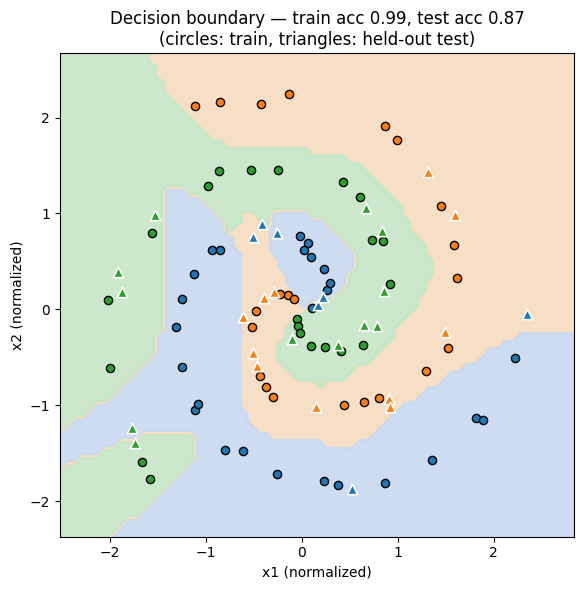

In [11]:
h = 0.08
x_min, x_max = Xn[:,0].min()-0.5, Xn[:,0].max()+0.5
y_min, y_max = Xn[:,1].min()-0.5, Xn[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([np.argmax([l.data for l in model([Value(a), Value(b)])]) for a, b in grid])
Z = Z.reshape(xx.shape)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#c9d9f0', '#f7dcc0', '#c7e6c7'])
pts = ['tab:blue', 'tab:orange', 'tab:green']
plt.figure(figsize=(6.5, 6))
plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.9)
for c in range(3):
    m_tr = ytr == c
    plt.scatter(Xtr[m_tr,0], Xtr[m_tr,1], c=pts[c], edgecolor='k', s=35)
    m_te = yte == c
    plt.scatter(Xte[m_te,0], Xte[m_te,1], c=pts[c], edgecolor='white', s=55, marker='^', linewidths=1.2)
plt.gca().set_aspect('equal')
plt.title(f'Decision boundary — train acc {tr_acc:.2f}, test acc {te_acc:.2f}\n(circles: train, triangles: held-out test)')
plt.xlabel('x1 (normalized)'); plt.ylabel('x2 (normalized)')
plt.tight_layout()
if SAVE_FIGS:
    ASSETS.mkdir(exist_ok=True)
    plt.savefig(ASSETS / 'decision_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

## What this shows, and where it stops

The scalar engine — three primitives and a handful of elementary functions — trains a real multi-class classifier end to end: the linear baseline fails at chance, the MLP wraps the spiral arms and generalizes to held-out points, and softmax + NLL falls straight out of the primitives with no special-casing.

Where it stops is honest and structural. This is a **scalar** engine: one `Value` per number, a Python loop per forward pass, no vectorization. That caps it at teaching scale — a hundred 2D points, not a real dataset — and the point was never speed but transparency: you can read every gradient. The test gap below train is the small-data reality (a few dozen points per class with overlap), not a bug. And the softmax here is the plain form; at larger logit magnitudes the log-sum-exp trick would be needed for numerical stability, which the makemore repo picks up. That's the next rung: same from-scratch discipline, more model.